# SHine-K — IEEE Access **원고 그림 전체(Fig. 1–8) 재현** 노트북 (v9)
**Run all 한 번**으로 원고의 시각화 8종을 전부 재생성합니다.

| 원고 그림 | 파일 | 방법 | 재현 수준 |
|---|---|---|---|
| Fig. 1–3 | `fig_arch` · `fig_dataflow` · `fig_workflow` | matplotlib 다이어그램 (Cell 2) | 결정적 렌더 — 동일 matplotlib 버전에서 **픽셀 동일**, 버전이 다르면 여백·안티에일리어싱 수 px 차이 가능 |
| Fig. 4–5 | `fig_twin` · `fig_live` | 공개 데모 콘솔 헤드리스 캡처 (Cell 5) | **동등 캡처** — 라이브 콘솔이라 시계·시뮬 수치는 실행마다 다름(구성·레이아웃·치수 동일) |
| Fig. 6–8 | `fig_confusion` · `fig_sweep_sensitivity` · `fig_sweep_operating` | 아카이브된 run 데이터 + 동일 플롯 코드 (Cell 4) | **동일 코드·동일 데이터** — 제출본은 Colab run이 생성한 원본 아티팩트이며, 이 셀은 같은 데이터에서 같은 코드로 다시 그림(동일 버전이면 픽셀 동일) |

- **Colab**: Drive 마운트 시 `…/최종_저널제출_IEEE_Access/figures/`에 저장 · **로컬**: `./figures/`
- 결과 그림(Fig. 6–8)의 원 데이터는 공개 저장소 [y3korea/SHine-K-](https://github.com/y3korea/SHine-K-)의 run 아카이브에서 가져오며,
  그 데이터를 만드는 평가 자체는 `SHine-K_full70_sweep_colab.ipynb` Run all로 재현됩니다.
- v9: Fig. 4–8 재현 셀 추가(전 시각화 Colab 재현) · v7→v8: 다이어그램 미세 조정


In [13]:
# === Cell 1 · 환경 감지 & 출력 경로 =========================================
%pip install -q "matplotlib==3.10.*"   # 제출본 그림 생성 버전 계열로 고정 — 픽셀 단위 재현 보장(Colab 기본과 일치)
import os
CAND = []
try:
    from google.colab import drive
    drive.mount("/content/drive")
    CAND.append("/content/drive/MyDrive/완석_구글자료/연구자료/20260721_컴퓨터정보_논문3/최종_저널제출_IEEE_Access/figures")
except Exception:
    pass
CAND.append("./figures")
OUT_DIR = next((p for p in CAND if os.path.isdir(os.path.dirname(p) or ".")), "./figures")
os.environ["OUT"] = OUT_DIR
print("figures →", OUT_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
figures → /content/drive/MyDrive/완석_구글자료/연구자료/20260721_컴퓨터정보_논문3/최종_저널제출_IEEE_Access/figures


In [14]:
# === Cell 2 · 그림 생성 코드(자체완결) ===
# -*- coding: utf-8 -*-
"""SHine-K IEEE Access diagram figures - FINAL v7 (2026-07-23)
fig_arch / fig_dataflow / fig_workflow. Local: python3 gen_figures_ieee.py -> ./figures
Colab: run gen_figures_colab.ipynb (auto-mounts Drive, saves into project figures/)
fig_workflow v6 (variant H): right-column chain gaps widened to 2.3 units so
each chain arrow has shaft+head+clearance (was 1.0-1.75: head-only stubs that
touched borders); tip-to-border gap unified at G=0.7 for all arrows; all arrowheads unified at MS=4.5 (half of v4) with a
uniform G=0.5-unit tip-to-border gap; the four sense->judgement arrows land on
fanned endpoints (y=38.5/35.0/31.0/27.5) so heads no longer pile on one point.
Layout: worker 13.5/gap 2, sense 15.5 (camera 4-line), judgement 20 @5.4pt
(floor: measured line width 17.9 units), diamond half-width 8 ("Risk type?" one
line, centered normal), diamond-column gap 4, Continue monitoring y=32.
"""

import os, matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch, Polygon

EDGE="#1a1a1a"; FILL="#ffffff"; GREY="#eef1f6"; TXT="#000000"; DGREY="#5a5f6b"
OUT=os.environ.get("OUT","./figures"); os.makedirs(OUT, exist_ok=True)
plt.rcParams.update({"font.family":"DejaVu Sans","text.color":TXT,
    "axes.edgecolor":EDGE,"savefig.facecolor":"white"})
W=7.16  # IEEE Access \textwidth in inches

def rect(ax,x,y,w,h,fc=FILL,lw=1.0,ls="-"):
    ax.add_patch(Rectangle((x,y),w,h,fc=fc,ec=EDGE,lw=lw,ls=ls,joinstyle="round"))
def txt(ax,x,y,s,fs=8,bold=False,it=False,ha="center",va="center",bg=None,color=TXT):
    bbox=dict(boxstyle="round,pad=0.22",fc=bg,ec="none") if bg else None
    ax.text(x,y,s,ha=ha,va=va,fontsize=fs,color=color,zorder=5,
            fontweight="bold" if bold else "normal",fontstyle="italic" if it else "normal",bbox=bbox)
def arr(ax,x1,y1,x2,y2,lw=1.1,ls="-",ms=13):
    ax.add_patch(FancyArrowPatch((x1,y1),(x2,y2),arrowstyle="-|>",mutation_scale=ms,
                 color=EDGE,lw=lw,ls=ls,shrinkA=1,shrinkB=1,zorder=3))
def newax(h_in,ymax):
    fig,ax=plt.subplots(figsize=(W,h_in)); ax.set_xlim(0,100); ax.set_ylim(0,ymax); ax.axis("off")
    ax.set_aspect("auto"); fig.patch.set_facecolor("white"); return fig,ax
def save(fig,name):
    fig.savefig(f"{OUT}/{name}",dpi=300,bbox_inches="tight",pad_inches=0.05); plt.close(fig)
    print(name,"ok")


MS=4.5   # workflow arrowhead size (half of previous)
G=0.7    # uniform arrowhead-to-border gap (data units)

def fig_arch():
    fig,ax=newax(2.9,100)
    stages=[("SENSE",["Vision\n(MediaPipe / YOLO)","Radar (mmWave)","Wearable (BLE)","Thermal / IoT"]),
            ("JUDGE",["Fusion (multimodal)","Risk predictor (LSTM)","REBA (33 keypoints)"]),
            ("ACT",["Nudge (haptic)","Health feedback","Task / staffing"]),
            ("CONNECT",["Emergency\n119 / e-Gen","Evacuation, roll-call","Realtime events\n(broker)"])]
    colw=22; gap=2; x0=3; y=16; H=74
    for i,(name,nodes) in enumerate(stages):
        x=x0+i*(colw+gap)
        rect(ax,x,y,colw,H,fc=GREY,lw=1.1)
        txt(ax,x+colw/2,y+H-7,name,fs=10.5,bold=True)
        top=y+H-15; bot=y+5; n=len(nodes); slot=(top-bot)/n
        for j,nd in enumerate(nodes):
            cy=top-slot*(j+0.5); bh=min(12 if "\n" in nd else 10,slot-2)
            rect(ax,x+0.8,cy-bh/2,colw-1.6,bh,fc=FILL,lw=0.9); txt(ax,x+colw/2,cy,nd,fs=7.1)
        if i<3: arr(ax,x+colw,y+H/2,x+colw+gap-G,y+H/2,lw=1.1,ms=4.5)   # 촉 4.5·간격 G 통일
    # 피드백 루프: CONNECT 하변 중앙 → 하단 레일(점선) → SENSE 하변으로 상향 진입(촉은 하변-G)
    dl=(0,(4,3)); y_rail=8.0
    xS=x0+colw/2; xC=x0+3*(colw+gap)+colw/2
    ax.plot([xC,xC],[y,y_rail],color=EDGE,lw=1.1,ls=dl)
    ax.plot([xC,xS],[y_rail,y_rail],color=EDGE,lw=1.1,ls=dl)
    ax.add_patch(FancyArrowPatch((xS,y_rail),(xS,y-G),arrowstyle="-|>",mutation_scale=4.5,
                 color=EDGE,lw=1.1,ls=dl,shrinkA=0,shrinkB=0,zorder=3))
    txt(ax,(xS+xC)/2,y_rail+3.8,"Feedback loop: personalized rest / stretch → re-measure",fs=8.2,it=True,bg="white")
    save(fig,"fig_arch.png")

# ---------- FIGURE 2: video-free boundary dataflow, figure* ----------
def fig_dataflow():
    fig,ax=newax(3.2,100)
    panels=[("Field\n(edge / browser)",[("Camera +\nMoveNet / YOLO",True),("Fire pixel analysis",True),("Wearable BLE\n(design)",False)]),
            ("Relay\n(message broker)",[("Event log\n(de-identified)",True),("Pseudonymous IDs",True),("119/SMS link\n(design)",False)]),
            ("Control center\n(web)",[("Multi-site monitoring",True),("Alerts / roll-call",True),("On-demand video\n(break-glass)",True)])]
    w=21; gap=15.5; x0=3; y=40; h=54
    xs=[x0+i*(w+gap) for i in range(3)]
    for i,(title,items) in enumerate(panels):
        x=xs[i]
        rect(ax,x,y,w,h,fc=GREY,lw=1.1)
        txt(ax,x+w/2,y+h-(8 if "\n" in title else 6),title,fs=7.8,bold=True)
        for j,(it,impl) in enumerate(items):
            cy=y+h-20-j*12
            bh=10.5 if "\n" in it else 8.5
            rect(ax,x+1.2,cy-bh/2,w-2.4,bh,fc=FILL,lw=0.9,ls=("-" if impl else "--"))
            txt(ax,x+w/2,cy,it,fs=6.7)
    ymid=y+h/2-4
    gx0=xs[0]+w; gx1=xs[1]
    arr(ax,gx0,ymid,gx1-G,ymid,lw=1.6)
    txt(ax,(gx0+gx1)/2,ymid+9.5,"17 skeleton\ncoords + events\n— NO pixels",fs=6.1,bold=True,bg="white")
    gx0=xs[1]+w; gx1=xs[2]; arr(ax,gx0,ymid,gx1-G,ymid,lw=1.6)
    txt(ax,(gx0+gx1)/2,ymid+6.5,"realtime push",fs=6.8,bg="white")
    rect(ax,6,10,88,17,fc=FILL,lw=1.0)
    ax.text(9,18.5,"During continuous monitoring no pixels (raw or anonymized) leave the site —\n"
                   "only de-identified skeleton coordinates and structured events. On-demand video\n"
                   "uses a consent-gated, time-limited (60 s), audit-logged 'break-glass' gate.",
            ha="left",va="center",ma="left",fontsize=7.2,color=TXT,zorder=5,linespacing=1.55)
    ax.plot([22,26],[3.2,3.2],color=EDGE,lw=1.6); ax.text(27.2,3.2,"implemented / validated",fontsize=7.5,va="center")
    ax.plot([57,61],[3.2,3.2],color=EDGE,lw=1.0,ls="--"); ax.text(62.2,3.2,"design target",fontsize=7.5,va="center")
    save(fig,"fig_dataflow.png")

# ---------- FIGURE 3: operational workflow, LANDSCAPE redesign, figure* ----------
def aitag(ax,x,y):
    rect(ax,x,y,3.2,2.4,fc=EDGE,lw=0)
    ax.text(x+1.6,y+1.2,"AI",ha="center",va="center",fontsize=5.6,color="white",fontweight="bold",zorder=6)
def bc(ax,cx,cy,w,h,s,ai=False,design=False,fs=7.2,tdy=0):
    rect(ax,cx-w/2,cy-h/2,w,h,fc=("#f5f7fc" if design else FILL),lw=1.0,ls=("--" if design else "-"))
    txt(ax,cx,cy+tdy,s,fs=fs,color=(DGREY if design else TXT))
    if ai: aitag(ax,cx-w/2+1.2,cy+h/2-3.6)

def warr(ax,x1,y1,x2,y2,lw=1.0,ls="-"):
    """workflow 전용: 촉 MS(소형)·수축 0 — 촉 끝이 지정 좌표(테두리-G)에 정확히 위치"""
    ax.add_patch(FancyArrowPatch((x1,y1),(x2,y2),arrowstyle="-|>",mutation_scale=MS,
                 color=EDGE,lw=lw,ls=ls,shrinkA=0,shrinkB=0,zorder=3))

def fig_workflow():
    fig,ax=newax(4.6,64)
    dl=(0,(4,3))
    # ---- 레이아웃 상수 (F안 확정치) ----
    ww,wgap,sw,jw,dhw,dgap = 13.5,2.0,15.5,20.0,8.0,4.0
    wx=2+ww/2; wr=2+ww
    sx=wr+wgap+sw/2; sright=sx+sw/2; sleft=sx-sw/2
    jx=sright+2.0+jw/2; jleft=jx-jw/2; jright=jx+jw/2
    dcx=jright+2.0+dhw; dcy=33
    rxl=dcx+dhw+dgap; rw=min(25.0,99.5-rxl); rx=rxl+rw/2
    cm_y=32.0
    # ---- 범례 ----
    ax.plot([3,6.6],[62.4,62.4],color=EDGE,lw=1.7); ax.text(7.6,62.4,"implemented / validated",fontsize=6.4,va="center")
    ax.plot([33,36.6],[62.4,62.4],color=EDGE,lw=1.0,ls="--"); ax.text(37.6,62.4,"design target",fontsize=6.4,va="center")
    ax.add_patch(Polygon([(53.5,63.6),(55,62.4),(53.5,61.2),(52,62.4)],closed=True,fc=FILL,ec=EDGE,lw=1.0))
    ax.text(56,62.4,"decision",fontsize=6.4,va="center")
    rect(ax,66,61.2,3.2,2.4,fc=EDGE,lw=0); ax.text(67.6,62.4,"AI",ha="center",va="center",fontsize=5.6,color="white",fontweight="bold")
    ax.text(70.4,62.4,"AI step",fontsize=6.4,va="center")
    # ---- 워커 ----
    bc(ax,wx,32,ww,9,"Worker on the\nshop floor",fs=6.4)
    # ---- 센서 열 + 분산 수렴 ----
    sense=[("Camera (edge AI)\nposture · fall\ncaught-in\nhelmet / mask / vest",True,False,52,13.0,-1.2,38.5),
           ("Wearable vitals\nHR / temp",False,True,38.5,9.5,0,35.0),
           ("Self check-in\nsleep / fatigue / pain",False,False,25.5,9.5,0,31.0),
           ("Environment IoT\ngas / noise",False,True,12.5,9.5,0,27.5)]
    for s,ai,de,cy,sh,tdy,jy in sense:
        bc(ax,sx,cy,sw,sh,s,ai=ai,design=de,fs=5.5,tdy=tdy)
        warr(ax,wr,32,sleft-G,cy)                    # 워커 → 센서 (좌변-G)
        warr(ax,sright,cy,jleft-G,jy)                # 센서 → 판정 (좌변-G, 세로 분산 종점)
    # ---- 판정 ----
    bc(ax,jx,33,jw,15,"Risk judgement:\nfall state machine + REBA\n(rule-based, validated)",ai=True,fs=5.4,tdy=-1.0)
    txt(ax,jx,22.6,"+ open agent harness: PoC ·\ninterface-level · not evaluated",fs=5.4,it=True,color=DGREY)
    # ---- 마름모 ----
    ax.add_patch(Polygon([(dcx,dcy+7),(dcx+dhw,dcy),(dcx,dcy-7),(dcx-dhw,dcy)],closed=True,fc=FILL,ec=EDGE,lw=1.0,zorder=2))
    txt(ax,dcx,dcy,"Risk type?",fs=6.4); txt(ax,dcx,36.3,"normal",fs=5.8,it=True,bg="white")
    warr(ax,jright,33,dcx-dhw-G,33)
    # ---- 우측 결과 열 ----
    # 사슬 구간 틈 2.3(화살표: 몸통+촉+간격), 그룹 사이 1.3 / Continue=32(마름모 정렬)
    yA,yAl,yE,yH,yP,yC = 59.65,48.6,38.8,23.95,12.9,2.95
    bc(ax,rx,yA,rw,8,"Acute hazard\nfall / fire / gas",fs=6.4)
    bc(ax,rx,yAl,rw,9.5,"Alert + evacuation\n& roll-call + 119/e-Gen\n(design)",design=True,fs=5.9)
    bc(ax,rx,yE,rw,5.5,"Emergency resolved",fs=6.4)
    bc(ax,rx,cm_y,rw,5.5,"Continue monitoring",fs=6.4)
    bc(ax,rx,yH,rw,8,"Health / ergonomic risk\nhigh REBA / fatigue",fs=5.9)
    bc(ax,rx,yP,rw,9.5,"Personalized recovery\ncoaching (rest/stretch)",ai=True,fs=5.9,tdy=-1.1)
    bc(ax,rx,yC,rw,5.8,"Confirm done · log\nadherence (design)",fs=5.9)
    warr(ax,rx,yA-4.0,rx,yAl+4.75+G)   # Acute 하변(55.65) → Alert 상변(53.35)+G
    warr(ax,rx,yAl-4.75,rx,yE+2.75+G)  # Alert 하변(43.85) → Emergency 상변(41.55)+G
    warr(ax,rx,yH-4.0,rx,yP+4.75+G)    # Health 하변(19.95) → Personalized 상변(17.65)+G
    warr(ax,rx,yP-4.75,rx,yC+2.9+G)    # Personalized 하변(8.15) → Confirm 상변(5.85)+G
    # ---- 분기 (촉은 좌변-G에서 정지) ----
    warr(ax,dcx,dcy+7,rxl-G,yA)
    txt(ax,(dcx+rxl)/2-3.2,(dcy+7+yA)/2+0.4,"acute",fs=5.8,it=True,bg="white")
    warr(ax,dcx+dhw,dcy,rxl-G,cm_y,ls=dl)
    warr(ax,dcx,dcy-7,rxl-G,yH)
    txt(ax,(dcx+rxl)/2-1.2,(dcy-7+yH)/2-1.8,"cumulative",fs=5.8,it=True,bg="white")
    # ---- 피드백 루프 (워커 하변, 촉은 하변-G 아래에서 정지) ----
    ax.plot([rxl,wx],[yC,yC],color=EDGE,lw=1.0,ls=dl)
    ax.add_patch(FancyArrowPatch((wx,yC),(wx,27.5-G),arrowstyle="-|>",mutation_scale=MS,
                 color=EDGE,lw=1.0,ls=dl,shrinkA=0,shrinkB=0,zorder=3))
    txt(ax,52,5.4,"Closed feedback loop: re-measure & adapt",fs=6.2,it=True,bg="white")
    save(fig,"fig_workflow.png")

fig_arch(); fig_dataflow(); fig_workflow()
print("figures written to", OUT)


fig_arch.png ok
fig_dataflow.png ok
fig_workflow.png ok
figures written to /content/drive/MyDrive/완석_구글자료/연구자료/20260721_컴퓨터정보_논문3/최종_저널제출_IEEE_Access/figures


fig_arch.png


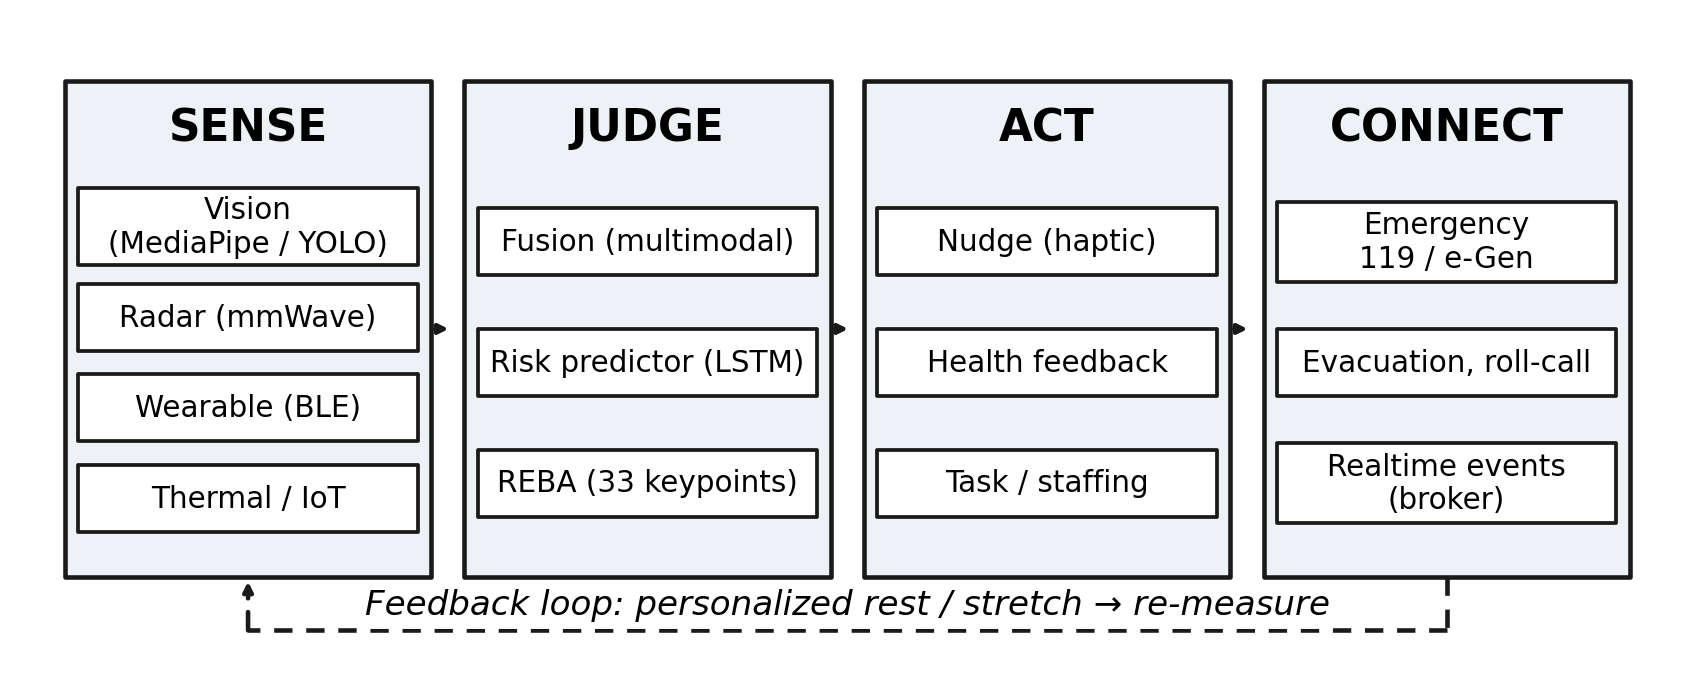

fig_dataflow.png


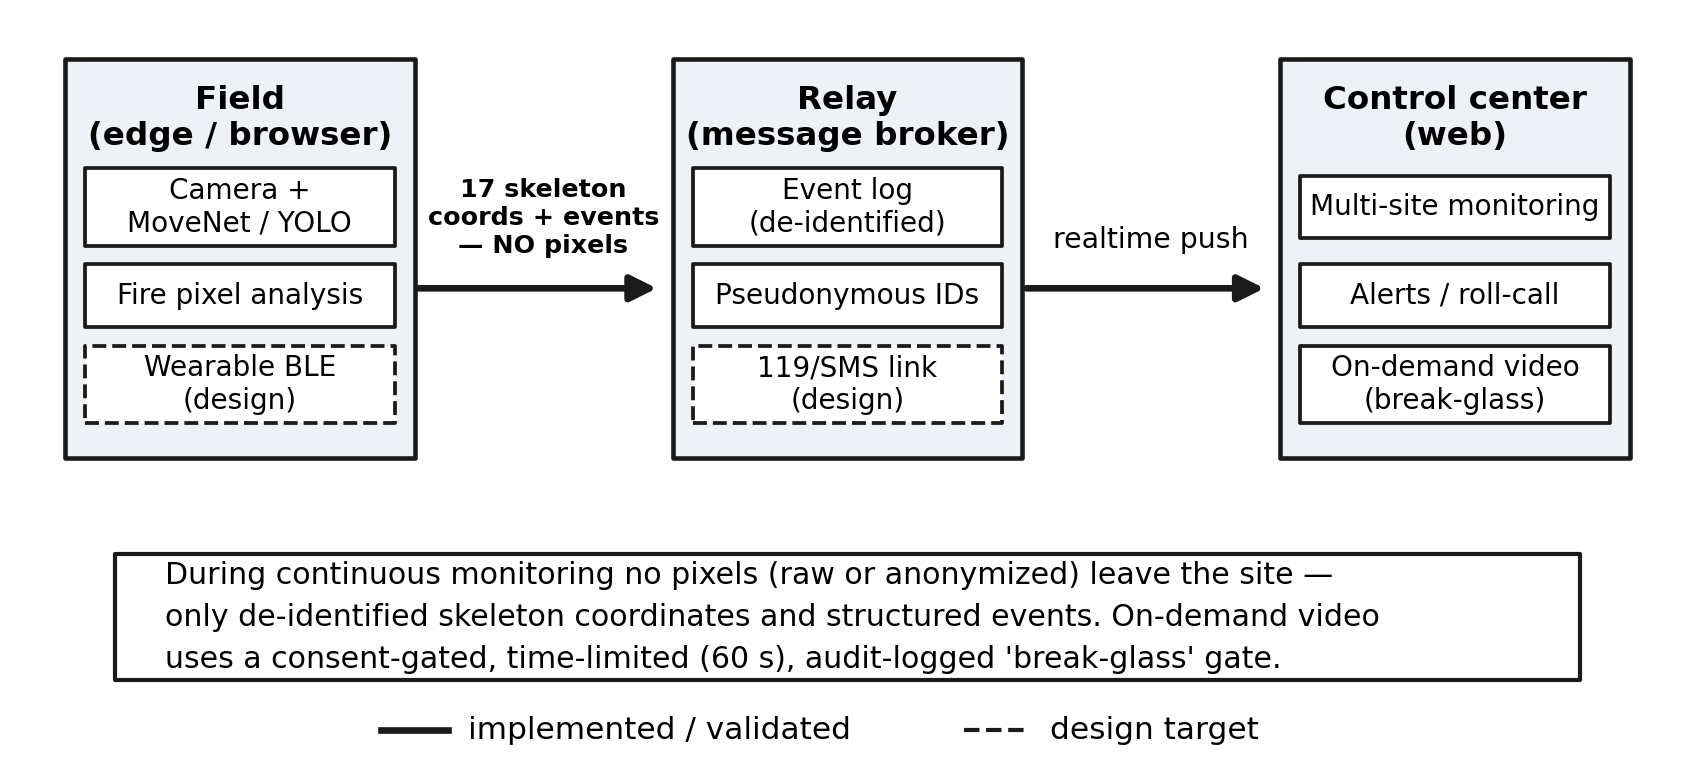

fig_workflow.png


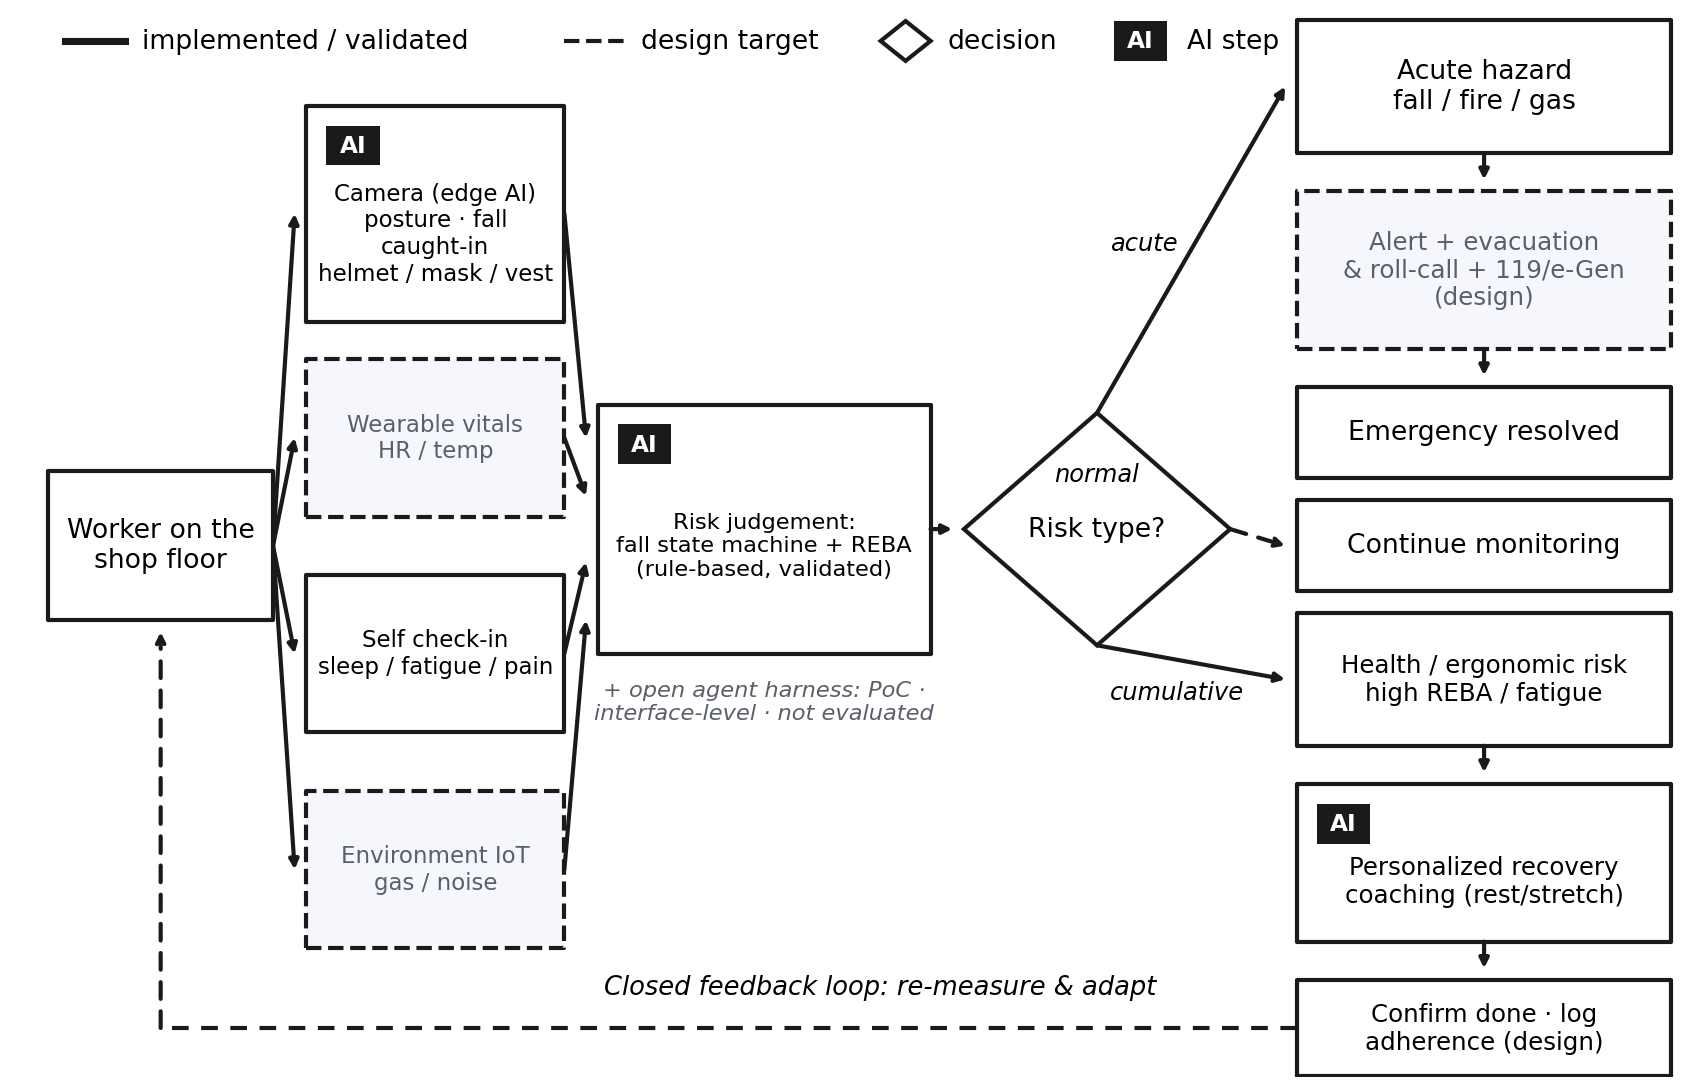

In [15]:
# === Cell 3 · 결과 미리보기 ==================================================
from IPython.display import Image as IPImage, display
for f in ["fig_arch.png","fig_dataflow.png","fig_workflow.png"]:
    print(f); display(IPImage(filename=os.path.join(OUT_DIR,f), width=760))


In [ ]:
# === Cell 4 · 결과 그림 재현 (Fig. 6–8) — 아카이브 run 데이터 + 원고와 동일한 플롯 코드 ===
import json, csv, io, os, urllib.request
import numpy as np
import matplotlib; matplotlib.use("Agg"); import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

os.makedirs(OUT_DIR, exist_ok=True)   # OUT_DIR는 Cell 1에서 결정
RAW = "https://raw.githubusercontent.com/y3korea/SHine-K-/main/output/"
def fetch(p): return urllib.request.urlopen(RAW + p).read()

# --- Fig. 6 · URFD confusion matrix — run_20260722_195713_full70의 계수에서 동일 코드로 ---
EV = json.loads(fetch("run_20260722_195713_full70/eval_metrics.json"))
TP,FP,FN,TN = (EV["counts"][k] for k in ("TP","FP","FN","TN"))
prec,rec,f1 = EV["precision"], EV["recall"], EV["f1"]
N_FALL,N_ADL = EV["n_fall"], EV["n_adl"]
cm=np.array([[TN,FP],[FN,TP]]); mx=max(1,cm.max())
fig,ax=plt.subplots(figsize=(3.5,3.3))
for (r_,c_),v in np.ndenumerate(cm):
    sh=0.93-0.30*(v/mx)
    ax.add_patch(Rectangle((c_,1-r_),1,1,fc=(sh,sh,sh),ec="#1a1a1a",lw=1.2))
    ax.text(c_+0.5,1-r_+0.5,int(v),ha="center",va="center",fontsize=16,fontweight="bold",color="#000")
ax.set_xlim(0,2); ax.set_ylim(0,2); ax.set_aspect("equal")
ax.set_xticks([0.5,1.5]); ax.set_xticklabels(["pred ADL","pred Fall"],fontsize=9)
ax.set_yticks([1.5,0.5]); ax.set_yticklabels(["true ADL","true Fall"],fontsize=9)
ax.tick_params(length=0)
for s in ax.spines.values(): s.set_visible(False)
ax.set_title("URFD fall detection (%d fall + %d ADL)\nPrecision %.2f  Recall %.2f  F1 %.2f"%(N_FALL,N_ADL,prec,rec,f1),fontsize=9.5,pad=8)
fig.savefig(os.path.join(OUT_DIR,"fig_confusion.png"), dpi=300, bbox_inches="tight", pad_inches=0.08); plt.close(fig)

# --- Fig. 7–8 · threshold sweep — run_20260723_131035의 sweep_results.csv에서 동일 코드로 ---
rows=list(csv.DictReader(io.StringIO(fetch("run_20260723_131035/sweep_results.csv").decode())))
for r in rows:
    for k in r: r[k]=float(r[k])
TILTS=[40,44,48,52,56,60,64]; WINDOWS=[300,500,700,900,1100]
f1_t=[next(r for r in rows if r["tilt"]==t and r["window"]==700)["f1"] for t in TILTS]
f1_w=[next(r for r in rows if r["tilt"]==52 and r["window"]==w)["f1"] for w in WINDOWS]
fig,ax=plt.subplots(1,2,figsize=(7.0,2.6))
ax[0].plot(TILTS,f1_t,"o-",color="#0072B2",ms=5); ax[0].axvline(52,ls="--",lw=0.9,color="0.4")
ax[0].set_xlabel("Tilt threshold (deg)"); ax[0].set_ylabel("F1"); ax[0].set_title("(a) F1 vs tilt (window = 700 ms)",fontsize=9)
ax[1].plot(WINDOWS,f1_w,"o-",color="#D55E00",ms=5); ax[1].axvline(700,ls="--",lw=0.9,color="0.4")
ax[1].set_xlabel("Confirmation window (ms)"); ax[1].set_ylabel("F1"); ax[1].set_title("(b) F1 vs window (tilt = 52°)",fontsize=9)
for a in ax: a.spines["top"].set_visible(False); a.spines["right"].set_visible(False)
fig.tight_layout(); fig.savefig(os.path.join(OUT_DIR,"fig_sweep_sensitivity.png"),dpi=300,bbox_inches="tight"); plt.close(fig)

fig,ax=plt.subplots(figsize=(3.6,3.4))
ax.scatter([r["fpr"] for r in rows],[r["recall"] for r in rows],s=22,c="#999999",label="grid (35 settings)")
dep=next(r for r in rows if r["tilt"]==52 and r["window"]==700)
ax.scatter([dep["fpr"]],[dep["recall"]],s=70,c="#D55E00",zorder=5,label="deployed (52°, 700 ms)")
ax.set_xlabel("False-positive rate"); ax.set_ylabel("Recall (TPR)")
ax.set_xlim(0,1); ax.set_ylim(0,1.02); ax.legend(frameon=False,fontsize=7.5,loc="lower right")
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
fig.tight_layout(); fig.savefig(os.path.join(OUT_DIR,"fig_sweep_operating.png"),dpi=300,bbox_inches="tight"); plt.close(fig)
print("fig_confusion / fig_sweep_sensitivity / fig_sweep_operating 저장 완료 →", OUT_DIR)


In [ ]:
# === Cell 5 · 프로토타입 스크린샷 재현 (Fig. 4–5) — 공개 데모 콘솔 헤드리스 캡처 ===
# 원본 캡처 레시피(Chrome --headless --window-size=1200,1000 --force-device-scale-factor=2)와
# 동일한 뷰포트/배율. 라이브 콘솔(시계·시뮬레이션)이라 픽셀 동일이 아닌 "동등 캡처"가 재현 기준입니다.
%pip -q install playwright
!playwright install --with-deps chromium >/dev/null 2>&1 || playwright install chromium
import os
from playwright.async_api import async_playwright
CAPS = [("fig_twin.png", "https://y3korea.github.io/shine-k/console.html?demo&light&en#twin", 20000),
        ("fig_live.png", "https://y3korea.github.io/shine-k/console.html?autoreplay&light&en#live", 9500)]
async def capture():
    async with async_playwright() as p:
        b = await p.chromium.launch()
        pg = await b.new_page(viewport={"width":1200,"height":1000}, device_scale_factor=2)
        for name, url, wait_ms in CAPS:
            await pg.goto(url, wait_until="load")
            await pg.wait_for_timeout(wait_ms)   # TF.js 모델 로드 + 시뮬 진행 대기(원본의 virtual-time-budget 대응)
            await pg.screenshot(path=os.path.join(OUT_DIR, name))
            print(name, "captured (2400x2000)")
        await b.close()
await capture()


In [ ]:
# === Cell 6 · 전체 미리보기 — 원고 그림 8종 ===
from IPython.display import Image as IPImage, display
for f in ["fig_arch.png","fig_dataflow.png","fig_workflow.png","fig_twin.png","fig_live.png",
          "fig_confusion.png","fig_sweep_sensitivity.png","fig_sweep_operating.png"]:
    p = os.path.join(OUT_DIR, f)
    print(("O " if os.path.exists(p) else "X ") + f)
    if os.path.exists(p): display(IPImage(filename=p, width=700))
